# Notebook 5: Baseline Modeling

## Project: Diabetes Glucose Analysis

In this notebook, we build baseline machine learning regression models to predict glucose values using the modeling-ready dataset created in Notebook 4.

The goal of this notebook is not to build the final best model yet. The goal is to create reliable baseline models that can be compared fairly across different data split strategies.

## Models Used

- Linear Regression
- Decision Tree Regression
- Random Forest Regression

## Evaluation Metrics

- MAE
- RMSE
- R² Score

## Split Strategies Compared

- Random train-test split
- Chronological train-test split
- Patient-level train-test split

## 1. Import Required Libraries

We import all libraries needed for data loading, modeling, evaluation, visualization, and saving results.

### Why this step is needed

Machine learning workflows require separate tools for data handling, model training, metrics, and visualizations.

### Consequences if skipped

The notebook will fail later because required functions such as `train_test_split`, `LinearRegression`, or `mean_absolute_error` will not be available.

In [1]:
# Data handling
import os
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Model evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Data splitting
from sklearn.model_selection import train_test_split, GroupShuffleSplit

# Save models and results
import joblib

# Warnings
import warnings
warnings.filterwarnings("ignore")

## 2. Universal Chart Styling Setup

This section sets one consistent visual style for all charts in this notebook.

### Why this step is needed

Using a global chart style makes the notebook look professional and consistent. It also avoids repeating style settings in every chart.

### Consequences if skipped

Charts may look inconsistent, harder to read, and less professional in the final GitHub version.

In [2]:
# Universal seaborn theme
sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="husl"
)

# Universal matplotlib settings
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 11
plt.rcParams["figure.titlesize"] = 18
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.edgecolor"] = "#333333"
plt.rcParams["axes.linewidth"] = 1
plt.rcParams["grid.alpha"] = 0.3

print("Universal chart styling applied successfully.")

Universal chart styling applied successfully.


## 3. Define File Paths

We define input and output paths clearly.

### Why this step is needed

Using paths in one place makes the notebook easier to maintain and prevents repeated hard-coded file locations.

### Consequences if skipped

File loading or saving may become confusing, and future changes to file paths would require editing multiple cells.

In [3]:
# Input files from previous notebooks
processed_data_path = "../data/processed/diabetes_glucose_processed.csv"
modeling_data_path = "../data/processed/modeling_ready_dataset.csv"
feature_list_path = "../data/processed/modeling_feature_list.csv"

# Output folders
models_output_dir = "../models"
reports_output_dir = "../reports"

# Create folders if they do not exist
os.makedirs(models_output_dir, exist_ok=True)
os.makedirs(reports_output_dir, exist_ok=True)

print("Paths defined successfully.")

Paths defined successfully.


## 4. Load Modeling-Ready Dataset

We load the modeling-ready dataset and the selected feature list created in Notebook 4.

### Why this step is needed

Notebook 5 should continue from Notebook 4 instead of repeating feature engineering and preprocessing.

### Consequences if skipped

The models will not have clean input data or a clear list of approved modeling features.

In [4]:
# Load modeling-ready dataset
df = pd.read_csv(modeling_data_path)

# Load selected feature list
feature_list_df = pd.read_csv(feature_list_path)

# Display basic information
print("Modeling dataset shape:", df.shape)
print("Feature list shape:", feature_list_df.shape)

df.head()

Modeling dataset shape: (309242, 21)
Feature list shape: (14, 1)


,time,glucose,calories,heart_rate,steps,basal_rate,bolus_volume_delivered,carb_input,patient_id,time_diff,...,hour,day,day_of_week,date,time_period,glucose_lag_1,glucose_lag_3,glucose_lag_6,glucose_rolling_30min,glucose_rolling_1hr
0,2018-06-13 19:10:00,312.0,10.1430,91.339623,48.0,0.075,0.0,0.0,HUPA0001P,0 days 00:05:00,...,19,13,2,2018-06-13,evening,313.0,324.0,332.0,318.500000,320.428571
1,2018-06-13 19:15:00,293.0,6.8425,89.893443,0.0,0.075,0.0,0.0,HUPA0001P,0 days 00:05:00,...,19,13,2,2018-06-13,evening,312.0,306.0,326.0,313.000000,317.000000
2,2018-06-13 19:20:00,303.0,5.2325,89.352941,0.0,0.075,0.0,0.0,HUPA0001P,0 days 00:05:00,...,19,13,2,2018-06-13,evening,293.0,313.0,330.0,308.500000,315.444444
3,2018-06-13 19:25:00,293.0,8.0500,89.778761,77.0,0.075,0.0,0.0,HUPA0001P,0 days 00:05:00,...,19,13,2,2018-06-13,evening,303.0,312.0,324.0,303.333333,313.200000
4,2018-06-13 19:30:00,271.0,17.7905,104.536232,124.0,0.075,0.0,0.0,HUPA0001P,0 days 00:05:00,...,19,13,2,2018-06-13,evening,293.0,293.0,306.0,297.500000,309.363636


# Load modeling-ready dataset
df = pd.read_csv(modeling_data_path)

# Load selected feature list
feature_list_df = pd.read_csv(feature_list_path)

# Display basic information
print("Modeling dataset shape:", df.shape)
print("Feature list shape:", feature_list_df.shape)

df.head()

In [5]:
df.columns

Index(['time', 'glucose', 'calories', 'heart_rate', 'steps', 'basal_rate',
       'bolus_volume_delivered', 'carb_input', 'patient_id', 'time_diff',
       'glucose_category', 'hour', 'day', 'day_of_week', 'date', 'time_period',
       'glucose_lag_1', 'glucose_lag_3', 'glucose_lag_6',
       'glucose_rolling_30min', 'glucose_rolling_1hr'],
      dtype='str')

In [6]:
feature_list_df.head()

,feature_name
0,calories
1,heart_rate
2,steps
3,basal_rate
4,bolus_volume_delivered


## 6. Define Target Variable and Feature Columns

The target variable is the value we want to predict. In this project, we predict glucose.

The feature columns are the input variables used by the models to make predictions.

### Why this step is needed

Machine learning models require a clear separation between input features `X` and target variable `y`.

### Consequences if skipped

The model may accidentally include the target as a feature, causing data leakage and unrealistic performance.

In [7]:
# Define target variable
target_col = "glucose"

# Extract feature column names from modeling_feature_list.csv
feature_cols = feature_list_df["feature_name"].tolist()

print("Number of features:", len(feature_cols))
feature_cols

print("Target variable:", target_col)
print("Number of features:", len(feature_cols))
print("Feature columns:")
feature_cols

Number of features: 14
Target variable: glucose
Number of features: 14
Feature columns:


['calories',
 'heart_rate',
 'steps',
 'basal_rate',
 'bolus_volume_delivered',
 'carb_input',
 'hour',
 'day',
 'day_of_week',
 'glucose_lag_1',
 'glucose_lag_3',
 'glucose_lag_6',
 'glucose_rolling_30min',
 'glucose_rolling_1hr']

## 7. Validate Target and Feature Availability

We confirm that all selected features and the target column exist in the dataset.

### Why this step is needed

This catches missing or mismatched column names before model training.

### Consequences if skipped

The notebook may fail later during model fitting, making debugging more difficult.

In [8]:
# Check missing columns
required_cols = feature_cols + [target_col]
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    print("Missing columns found:")
    print(missing_cols)
else:
    print("All required columns are present.")

All required columns are present.


## 8. Prepare Modeling Data

We create the feature matrix `X` and target vector `y`.

Rows with missing values in selected features or target are removed.

### Why this step is needed

Most scikit-learn models cannot train with missing values.

### Consequences if skipped

Model training may fail or produce unreliable results.

In [9]:
# Keep only required columns
model_df = df[required_cols].copy()

# Drop rows with missing values
before_shape = model_df.shape
model_df = model_df.dropna()
after_shape = model_df.shape

print("Shape before dropping missing values:", before_shape)
print("Shape after dropping missing values:", after_shape)
print("Rows removed:", before_shape[0] - after_shape[0])

# Define X and y
X = model_df[feature_cols]
y = model_df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

Shape before dropping missing values: (309242, 15)
Shape after dropping missing values: (309242, 15)
Rows removed: 0
X shape: (309242, 14)
y shape: (309242,)


## 9. Review Target Variable Distribution

We visualize the glucose distribution before modeling.

### Why this step is needed

Understanding the target distribution helps interpret model errors and detect unusual values.

### Consequences if skipped

Poor model performance may be harder to explain because we do not understand the range and spread of glucose values.

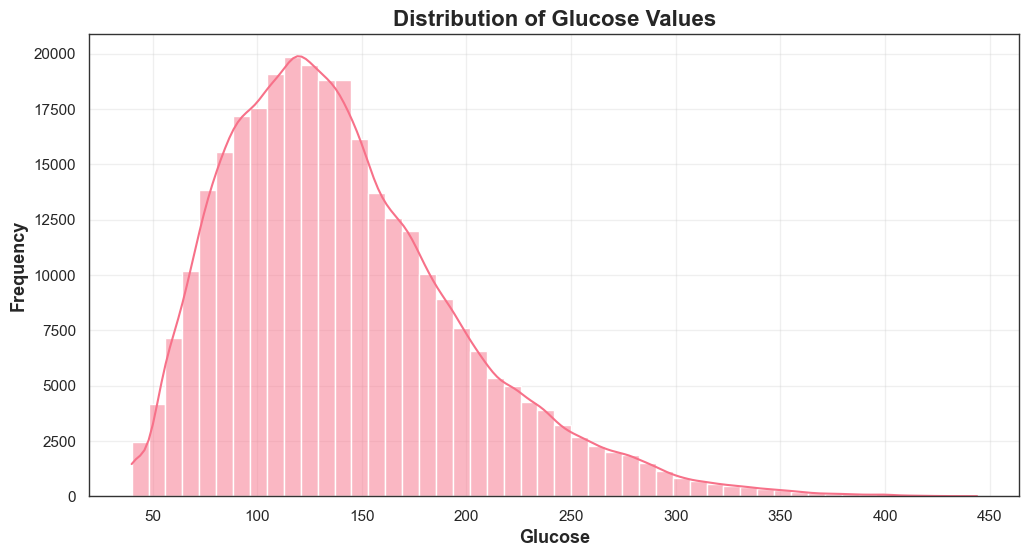

In [10]:
plt.figure()
sns.histplot(y, bins=50, kde=True)
plt.title("Distribution of Glucose Values")
plt.xlabel("Glucose")
plt.ylabel("Frequency")
plt.show()

In [11]:
y.describe()

count    309242.000000
mean        141.430195
std          57.077809
min          40.000000
25%          99.666667
50%         132.000000
75%         173.000000
max         444.000000
Name: glucose, dtype: float64

## 10. Define Model Evaluation Function

We create a reusable function to calculate MAE, RMSE, and R².

### Metric Explanation

### MAE — Mean Absolute Error

MAE measures the average absolute difference between actual and predicted glucose values.

Lower MAE means better performance.

### RMSE — Root Mean Squared Error

RMSE also measures prediction error, but it penalizes large errors more strongly than MAE.

Lower RMSE means better performance.

### R² Score

R² measures how much variation in glucose values is explained by the model.

A score closer to 1 is better. A score near 0 means the model does not explain much variation.

### Why this step is needed

A reusable evaluation function keeps results consistent across all models and split strategies.

### Consequences if skipped

Metrics may be calculated inconsistently, making model comparison unreliable.

In [12]:
def evaluate_model(model_name, split_name, y_true, y_pred):
    """
    Evaluate regression model performance.
    
    Parameters:
        model_name: Name of the model
        split_name: Name of the split strategy
        y_true: Actual target values
        y_pred: Predicted target values
    
    Returns:
        Dictionary containing evaluation metrics
    """
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    return {
        "model": model_name,
        "split_strategy": split_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

## 11. Define Baseline Models

We define three baseline regression models.

### Linear Regression

A simple model that assumes a linear relationship between features and glucose.

### Decision Tree Regression

A non-linear model that splits the data into decision rules.

### Random Forest Regression

An ensemble model that combines many decision trees to improve stability and accuracy.

### Why this step is needed

Using different model types helps compare simple, interpretable models with more flexible non-linear models.

### Consequences if skipped

We would not know whether a simple model is enough or whether more complex models improve prediction.

In [13]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regression": DecisionTreeRegressor(
        random_state=42,
        max_depth=10,
        min_samples_leaf=20
    ),
    "Random Forest Regression": RandomForestRegressor(
        random_state=42,
        n_estimators=100,
        max_depth=12,
        min_samples_leaf=20,
        n_jobs=-1
    )
}

models

{'Linear Regression': LinearRegression(),
 'Decision Tree Regression': DecisionTreeRegressor(max_depth=10, min_samples_leaf=20, random_state=42),
 'Random Forest Regression': RandomForestRegressor(max_depth=12, min_samples_leaf=20, n_jobs=-1,
                       random_state=42)}

## 12. Random Train-Test Split

A random split divides rows randomly into training and testing data.

### Why this step is needed

This is a common baseline split strategy and gives a quick estimate of model performance.

### Consequences if skipped

We lose a simple reference point for model comparison.

### Important Note

For time-series and patient-level data, random split can produce overly optimistic results because similar records from the same patient or nearby time periods may appear in both training and testing data.

In [14]:
X_train_random, X_test_random, y_train_random, y_test_random = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Random split completed.")
print("Training shape:", X_train_random.shape)
print("Testing shape:", X_test_random.shape)

Random split completed.
Training shape: (247393, 14)
Testing shape: (61849, 14)


## 13. Train and Evaluate Models Using Random Split

Each baseline model is trained on the random training set and evaluated on the random test set.

### Why this step is needed

This gives the first comparison of model performance.

### Consequences if skipped

We would not know how models perform under a standard split strategy.

In [15]:
results = []

trained_models = {}

for model_name, model in models.items():
    print(f"Training {model_name} on random split...")
    
    model.fit(X_train_random, y_train_random)
    y_pred = model.predict(X_test_random)
    
    result = evaluate_model(
        model_name=model_name,
        split_name="Random Split",
        y_true=y_test_random,
        y_pred=y_pred
    )
    
    results.append(result)
    trained_models[f"{model_name}_Random Split"] = model

print("Random split modeling completed.")

Training Linear Regression on random split...
Training Decision Tree Regression on random split...
Training Random Forest Regression on random split...
Random split modeling completed.


In [16]:
random_results_df = pd.DataFrame(results)
random_results_df

,model,split_strategy,MAE,RMSE,R2
0,Linear Regression,Random Split,2.178058,4.644898,0.993373
1,Decision Tree Regression,Random Split,2.119275,4.456281,0.993901
2,Random Forest Regression,Random Split,1.682843,4.188599,0.994611


## 14. Chronological Train-Test Split

A chronological split uses earlier records for training and later records for testing.

### Why this step is needed

Because glucose data is time-series data, chronological splitting better simulates real-world prediction.

### Consequences if skipped

The model may appear better than it really is because future-like information may leak into training through random splitting.

In [17]:
# Reload full modeling dataframe with time column if available
df_chrono = df.copy()

if "time" in df_chrono.columns:
    df_chrono["time"] = pd.to_datetime(df_chrono["time"], errors="coerce")
    df_chrono = df_chrono.dropna(subset=["time"])
    df_chrono = df_chrono.sort_values("time")
    
    chrono_model_df = df_chrono[required_cols + ["time"]].dropna()
    
    split_index = int(len(chrono_model_df) * 0.8)
    
    train_chrono = chrono_model_df.iloc[:split_index]
    test_chrono = chrono_model_df.iloc[split_index:]
    
    X_train_chrono = train_chrono[feature_cols]
    y_train_chrono = train_chrono[target_col]
    
    X_test_chrono = test_chrono[feature_cols]
    y_test_chrono = test_chrono[target_col]
    
    print("Chronological split completed.")
    print("Training shape:", X_train_chrono.shape)
    print("Testing shape:", X_test_chrono.shape)
    print("Training time range:", train_chrono["time"].min(), "to", train_chrono["time"].max())
    print("Testing time range:", test_chrono["time"].min(), "to", test_chrono["time"].max())

else:
    print("Column 'time' not found. Chronological split cannot be performed.")

Chronological split completed.
Training shape: (247393, 14)
Testing shape: (61849, 14)
Training time range: 2018-06-13 19:10:00 to 2021-09-19 01:35:00
Testing time range: 2021-09-19 01:40:00 to 2022-05-18 12:15:00


## 15. Train and Evaluate Models Using Chronological Split

Each model is trained on earlier time periods and tested on later time periods.

### Why this step is needed

This tests whether the model can generalize to future glucose readings.

### Consequences if skipped

We may overestimate model performance in real-world forecasting situations.

In [18]:
if "time" in df.columns:
    for model_name, model in models.items():
        print(f"Training {model_name} on chronological split...")
        
        model.fit(X_train_chrono, y_train_chrono)
        y_pred = model.predict(X_test_chrono)
        
        result = evaluate_model(
            model_name=model_name,
            split_name="Chronological Split",
            y_true=y_test_chrono,
            y_pred=y_pred
        )
        
        results.append(result)
        trained_models[f"{model_name}_Chronological Split"] = model

    print("Chronological split modeling completed.")
else:
    print("Skipped chronological modeling because time column is unavailable.")

Training Linear Regression on chronological split...
Training Decision Tree Regression on chronological split...
Training Random Forest Regression on chronological split...
Chronological split modeling completed.


## 16. Patient-Level Train-Test Split

A patient-level split ensures that patients in the test set are not present in the training set.

### Why this step is needed

This evaluates whether a model trained on some patients can generalize to completely unseen patients.

### Consequences if skipped

The model may look strong because it has already learned patterns from the same patients during training.

In [19]:
df_patient = df.copy()

if "patient_id" in df_patient.columns:
    patient_model_df = df_patient[required_cols + ["patient_id"]].dropna()
    
    groups = patient_model_df["patient_id"]
    
    group_split = GroupShuffleSplit(
        n_splits=1,
        test_size=0.2,
        random_state=42
    )
    
    train_idx, test_idx = next(group_split.split(patient_model_df, groups=groups))
    
    train_patient = patient_model_df.iloc[train_idx]
    test_patient = patient_model_df.iloc[test_idx]
    
    X_train_patient = train_patient[feature_cols]
    y_train_patient = train_patient[target_col]
    
    X_test_patient = test_patient[feature_cols]
    y_test_patient = test_patient[target_col]
    
    print("Patient-level split completed.")
    print("Training shape:", X_train_patient.shape)
    print("Testing shape:", X_test_patient.shape)
    print("Training patients:", train_patient["patient_id"].nunique())
    print("Testing patients:", test_patient["patient_id"].nunique())
    print("Patient overlap:", set(train_patient["patient_id"]).intersection(set(test_patient["patient_id"])))

else:
    print("Column 'patient_id' not found. Patient-level split cannot be performed.")

Patient-level split completed.
Training shape: (130240, 14)
Testing shape: (179002, 14)
Training patients: 20
Testing patients: 5
Patient overlap: set()


## 17. Train and Evaluate Models Using Patient-Level Split

Each model is trained on one group of patients and tested on completely unseen patients.

### Why this step is needed

This is important for healthcare-related datasets because new patients may have different glucose patterns.

### Consequences if skipped

The model may not be properly tested for generalization to new patients.

In [20]:
if "patient_id" in df.columns:
    for model_name, model in models.items():
        print(f"Training {model_name} on patient-level split...")
        
        model.fit(X_train_patient, y_train_patient)
        y_pred = model.predict(X_test_patient)
        
        result = evaluate_model(
            model_name=model_name,
            split_name="Patient-Level Split",
            y_true=y_test_patient,
            y_pred=y_pred
        )
        
        results.append(result)
        trained_models[f"{model_name}_Patient-Level Split"] = model

    print("Patient-level split modeling completed.")
else:
    print("Skipped patient-level modeling because patient_id column is unavailable.")

Training Linear Regression on patient-level split...
Training Decision Tree Regression on patient-level split...
Training Random Forest Regression on patient-level split...
Patient-level split modeling completed.


if "patient_id" in df.columns:
    for model_name, model in models.items():
        print(f"Training {model_name} on patient-level split...")
        
        model.fit(X_train_patient, y_train_patient)
        y_pred = model.predict(X_test_patient)
        
        result = evaluate_model(
            model_name=model_name,
            split_name="Patient-Level Split",
            y_true=y_test_patient,
            y_pred=y_pred
        )
        
        results.append(result)
        trained_models[f"{model_name}_Patient-Level Split"] = model

    print("Patient-level split modeling completed.")
else:
    print("Skipped patient-level modeling because patient_id column is unavailable.")

In [21]:
results_df = pd.DataFrame(results)

# Sort by RMSE because lower RMSE is better
results_df = results_df.sort_values(by="RMSE", ascending=True).reset_index(drop=True)

results_df

,model,split_strategy,MAE,RMSE,R2
0,Random Forest Regression,Chronological Split,1.231959,2.210512,0.997142
1,Decision Tree Regression,Chronological Split,1.661097,2.652242,0.995886
2,Linear Regression,Chronological Split,1.808094,2.717967,0.995679
3,Random Forest Regression,Random Split,1.682843,4.188599,0.994611
4,Decision Tree Regression,Random Split,2.119275,4.456281,0.993901
5,Linear Regression,Random Split,2.178058,4.644898,0.993373
6,Random Forest Regression,Patient-Level Split,1.719092,5.058404,0.989678
7,Decision Tree Regression,Patient-Level Split,2.162416,5.257784,0.988848
8,Linear Regression,Patient-Level Split,1.677873,6.303409,0.983971


## 19. Compare Models Using MAE

This chart compares the Mean Absolute Error across models and split strategies.

### Why this step is needed

MAE is easy to interpret because it is in the same unit as glucose.

### Consequences if skipped

We lose a simple visual comparison of average prediction error.

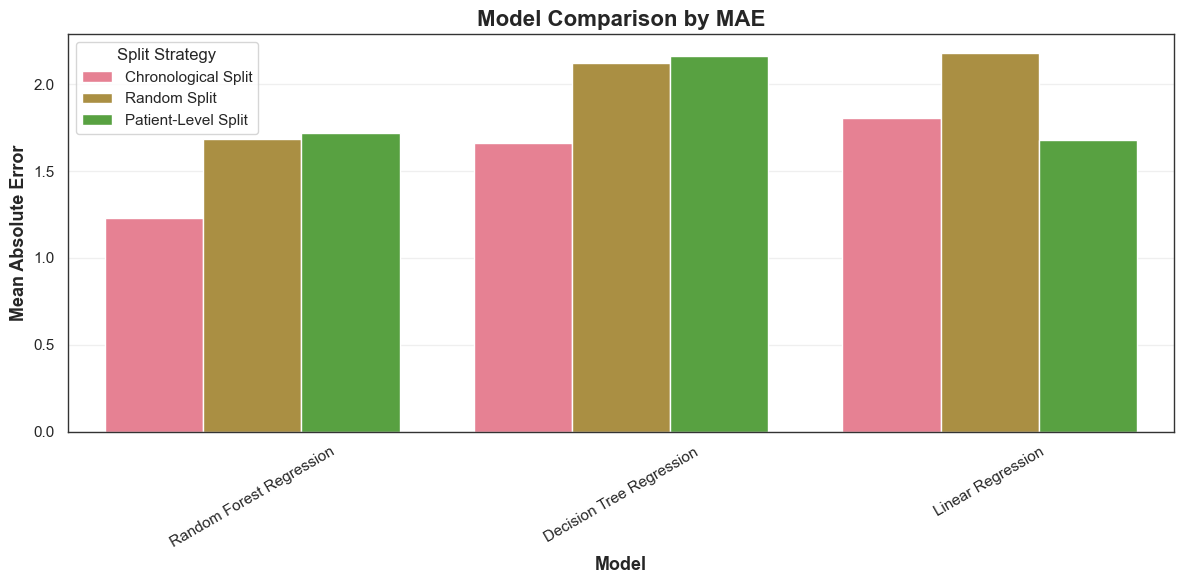

In [22]:
plt.figure()
sns.barplot(
    data=results_df,
    x="model",
    y="MAE",
    hue="split_strategy"
)
plt.title("Model Comparison by MAE")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=30)
plt.legend(title="Split Strategy")
plt.tight_layout()
plt.show()

## 20. Compare Models Using RMSE

This chart compares RMSE across models and split strategies.

### Why this step is needed

RMSE is useful because it penalizes large prediction errors more strongly.

### Consequences if skipped

We may miss models that occasionally make large errors.

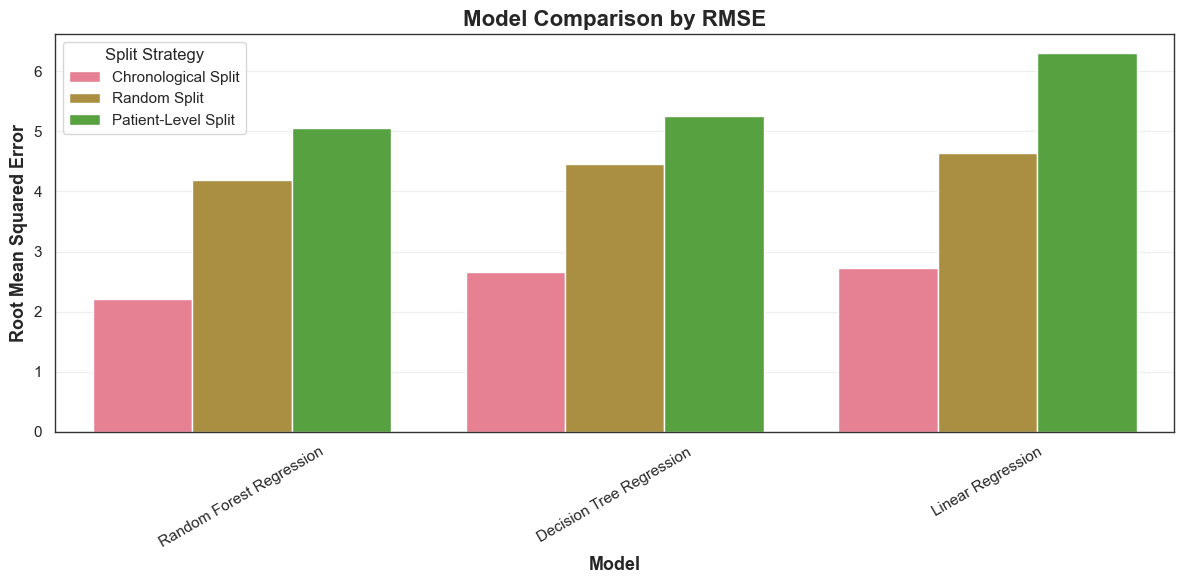

In [23]:
plt.figure()
sns.barplot(
    data=results_df,
    x="model",
    y="RMSE",
    hue="split_strategy"
)
plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("Root Mean Squared Error")
plt.xticks(rotation=30)
plt.legend(title="Split Strategy")
plt.tight_layout()
plt.show()

## 21. Compare Models Using R² Score

This chart compares how much variation in glucose values each model explains.

### Why this step is needed

R² helps evaluate how well the model captures overall glucose patterns.

### Consequences if skipped

We would only understand prediction error, not how much variation the model explains.

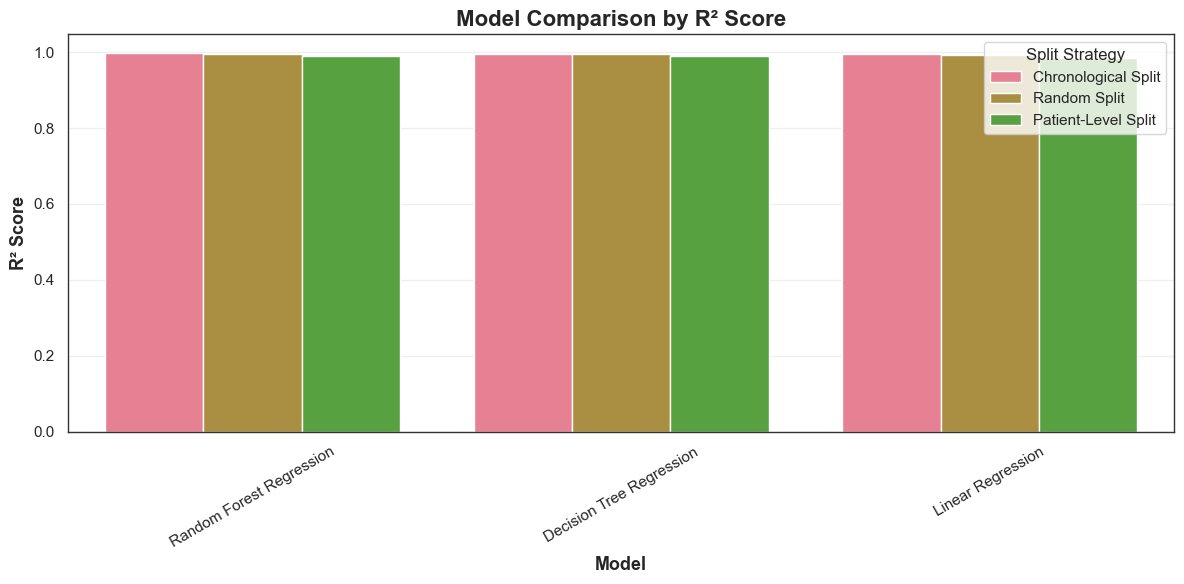

In [24]:
plt.figure()
sns.barplot(
    data=results_df,
    x="model",
    y="R2",
    hue="split_strategy"
)
plt.title("Model Comparison by R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=30)
plt.legend(title="Split Strategy")
plt.tight_layout()
plt.show()

## 22. Select Best Baseline Model

We select the best baseline model based on the lowest RMSE.

### Why this step is needed

Choosing one best baseline gives us a reference model for future improvement.

### Consequences if skipped

There will be no clear baseline to compare against in future notebooks.

In [25]:
best_result = results_df.iloc[0]

best_model_name = best_result["model"]
best_split_strategy = best_result["split_strategy"]
best_key = f"{best_model_name}_{best_split_strategy}"

best_model = trained_models[best_key]

print("Best baseline model:")
print("Model:", best_model_name)
print("Split strategy:", best_split_strategy)
print("MAE:", best_result["MAE"])
print("RMSE:", best_result["RMSE"])
print("R²:", best_result["R2"])

Best baseline model:
Model: Random Forest Regression
Split strategy: Chronological Split
MAE: 1.231959389392714
RMSE: 2.2105115989944273
R²: 0.9971421016343223


## 23. Generate Predictions for Best Model

We recreate the correct test set for the best model and generate predictions.

### Why this step is needed

Predictions are needed for residual analysis and actual vs predicted visualizations.

### Consequences if skipped

We cannot evaluate where the model is making mistakes.

In [26]:
if best_split_strategy == "Random Split":
    X_test_best = X_test_random
    y_test_best = y_test_random

elif best_split_strategy == "Chronological Split":
    X_test_best = X_test_chrono
    y_test_best = y_test_chrono

elif best_split_strategy == "Patient-Level Split":
    X_test_best = X_test_patient
    y_test_best = y_test_patient

else:
    raise ValueError("Unknown split strategy.")

best_predictions = best_model.predict(X_test_best)

prediction_df = pd.DataFrame({
    "actual_glucose": y_test_best.values,
    "predicted_glucose": best_predictions
})

prediction_df["residual"] = prediction_df["actual_glucose"] - prediction_df["predicted_glucose"]

prediction_df.head()

,actual_glucose,predicted_glucose,residual
0,157.333333,155.092687,2.240647
1,163.000000,162.254617,0.745383
2,166.000000,165.719853,0.280147
3,169.000000,168.856117,0.143883
4,172.000000,170.031500,1.968500


## 24. Actual vs Predicted Glucose Values

This plot compares actual glucose values with predicted glucose values.

### Why this step is needed

A strong model should have points close to the diagonal line.

### Consequences if skipped

We may only rely on metrics and miss visual evidence of poor prediction behavior.

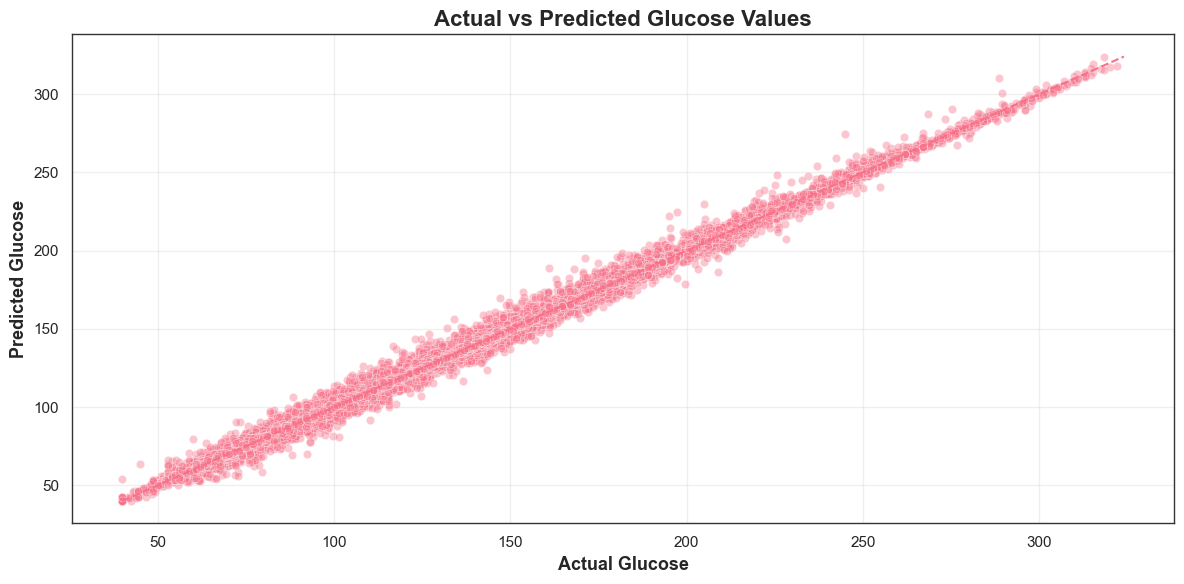

In [27]:
plt.figure()
sns.scatterplot(
    data=prediction_df,
    x="actual_glucose",
    y="predicted_glucose",
    alpha=0.4
)

min_val = min(prediction_df["actual_glucose"].min(), prediction_df["predicted_glucose"].min())
max_val = max(prediction_df["actual_glucose"].max(), prediction_df["predicted_glucose"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.title("Actual vs Predicted Glucose Values")
plt.xlabel("Actual Glucose")
plt.ylabel("Predicted Glucose")
plt.tight_layout()
plt.show()

## 25. Residual Distribution

Residuals are the differences between actual and predicted values.

Residual = Actual Glucose - Predicted Glucose

### Why this step is needed

Residual analysis helps determine whether errors are centered around zero or biased.

### Consequences if skipped

We may not notice systematic overprediction or underprediction.

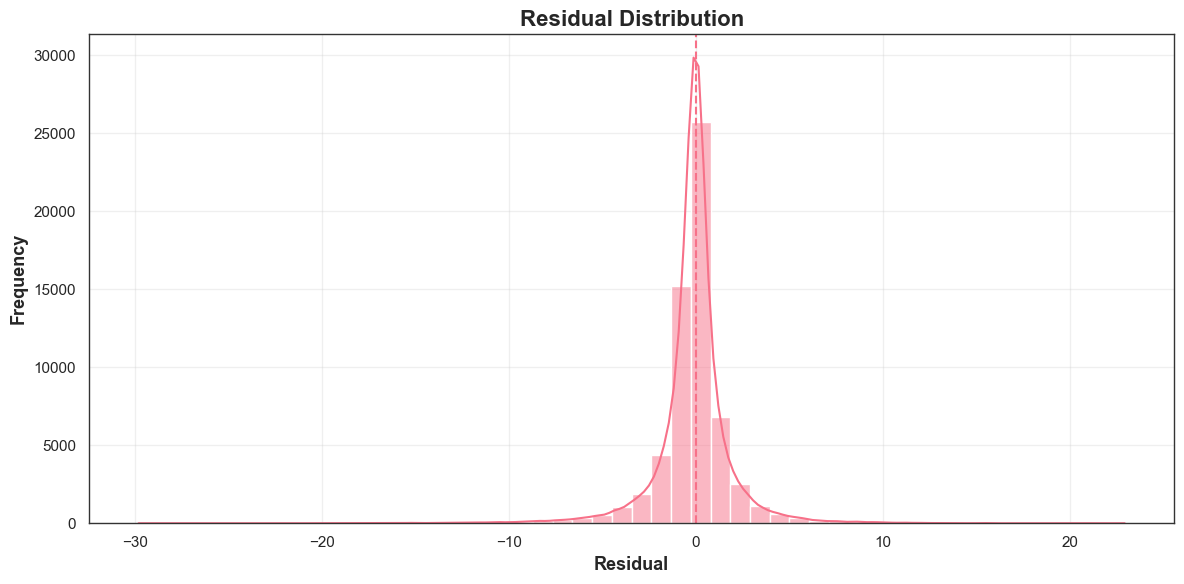

In [28]:
plt.figure()
sns.histplot(
    prediction_df["residual"],
    bins=50,
    kde=True
)
plt.axvline(0, linestyle="--")
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 26. Residuals vs Predicted Values

This plot checks whether prediction errors change depending on predicted glucose levels.

### Why this step is needed

A good model should have residuals randomly scattered around zero.

### Consequences if skipped

We may miss patterns showing that the model performs poorly at high or low glucose levels.

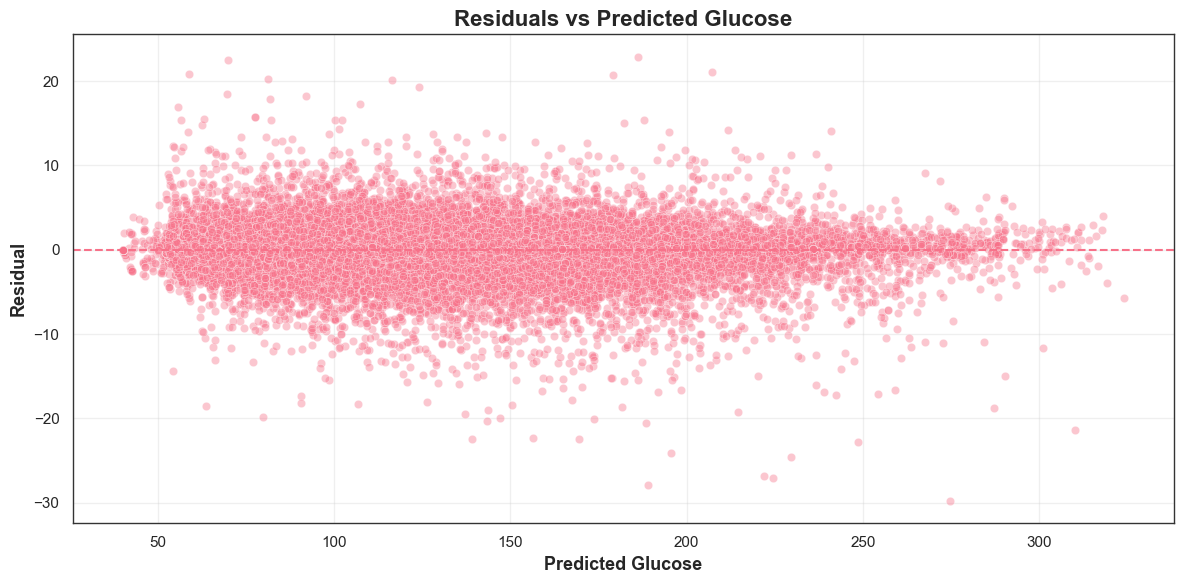

In [29]:
plt.figure()
sns.scatterplot(
    data=prediction_df,
    x="predicted_glucose",
    y="residual",
    alpha=0.4
)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Predicted Glucose")
plt.xlabel("Predicted Glucose")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

## 27. Feature Importance

For tree-based models, feature importance shows which features were most useful for prediction.

### Why this step is needed

Feature importance helps interpret the model and understand which variables contribute most to glucose prediction.

### Consequences if skipped

The model remains harder to explain, especially for non-linear models.

In [30]:
if hasattr(best_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": best_model.feature_importances_
    }).sort_values(by="importance", ascending=False)

    importance_df.head(20)

else:
    print("The best model does not provide feature_importances_.")

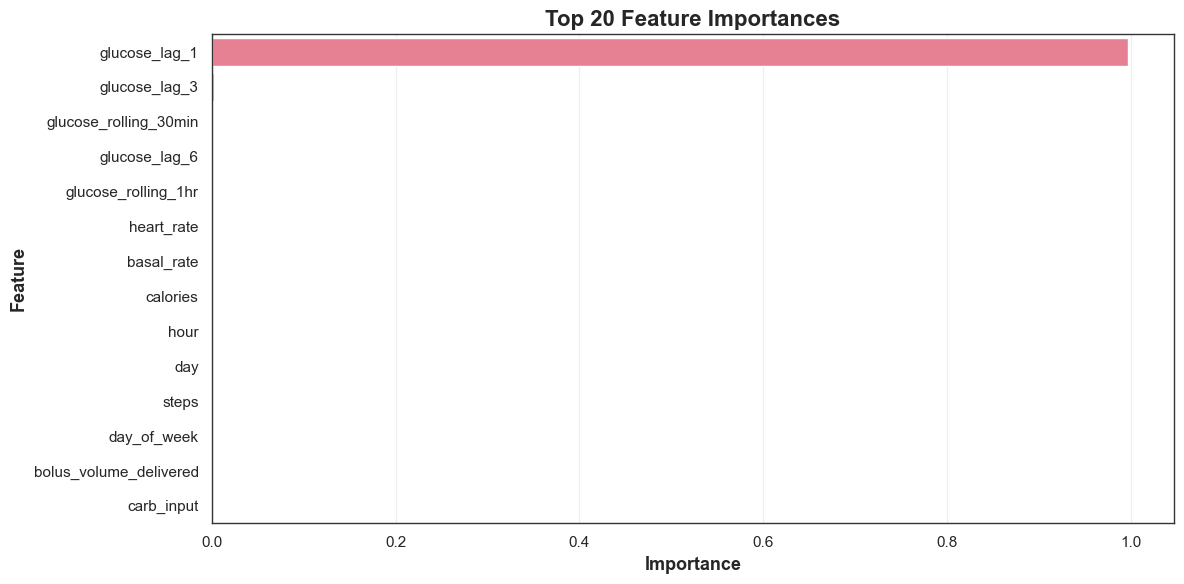

In [31]:
if hasattr(best_model, "feature_importances_"):
    top_importance_df = importance_df.head(20)

    plt.figure()
    sns.barplot(
        data=top_importance_df,
        x="importance",
        y="feature"
    )
    plt.title("Top 20 Feature Importances")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

## 28. Linear Regression Coefficients

If Linear Regression is used, coefficients show the direction and strength of each feature relationship with glucose.

### Why this step is needed

Linear coefficients make the model more interpretable.

### Consequences if skipped

We miss an opportunity to understand simple linear relationships in the data.

In [32]:
linear_model_key = "Linear Regression_Random Split"

if linear_model_key in trained_models:
    linear_model = trained_models[linear_model_key]

    coef_df = pd.DataFrame({
        "feature": feature_cols,
        "coefficient": linear_model.coef_
    })

    coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
    coef_df = coef_df.sort_values(by="abs_coefficient", ascending=False)

    coef_df.head(20)
else:
    print("Linear Regression model not available for coefficient analysis.")

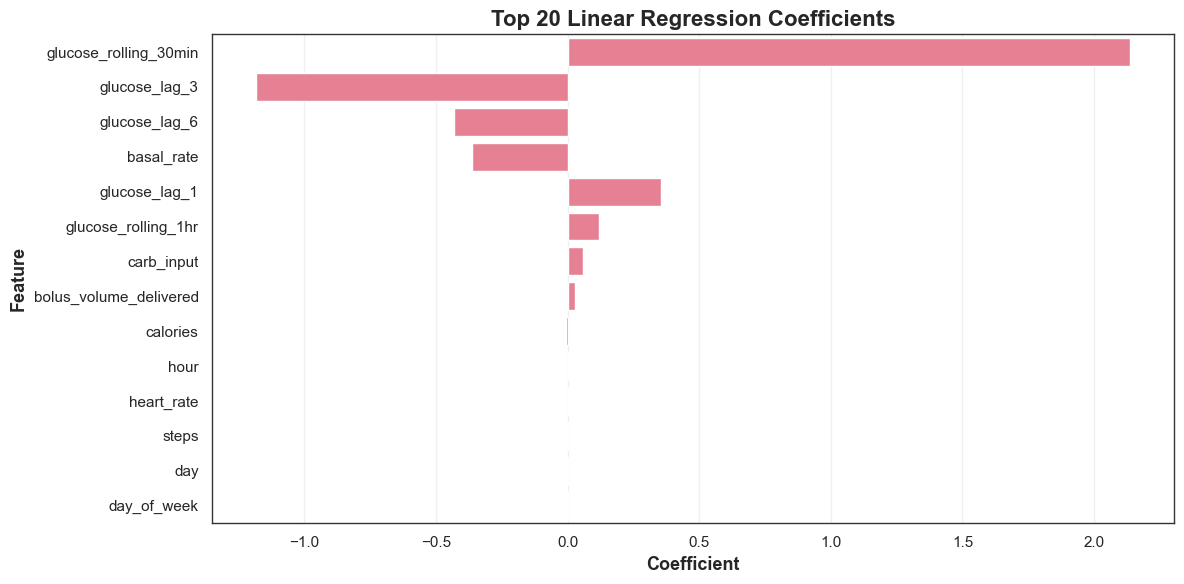

In [33]:
if linear_model_key in trained_models:
    top_coef_df = coef_df.head(20)

    plt.figure()
    sns.barplot(
        data=top_coef_df,
        x="coefficient",
        y="feature"
    )
    plt.title("Top 20 Linear Regression Coefficients")
    plt.xlabel("Coefficient")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

## 29. Check for Overfitting

Overfitting happens when a model performs very well on training data but poorly on test data.

### Why this step is needed

Baseline models should generalize well, not just memorize training data.

### Consequences if skipped

We may choose a model that looks good but performs poorly on new data.

In [34]:
overfitting_results = []

for model_name, model in models.items():
    model.fit(X_train_random, y_train_random)
    
    train_pred = model.predict(X_train_random)
    test_pred = model.predict(X_test_random)
    
    train_rmse = np.sqrt(mean_squared_error(y_train_random, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test_random, test_pred))
    
    overfitting_results.append({
        "model": model_name,
        "train_RMSE": train_rmse,
        "test_RMSE": test_rmse,
        "RMSE_gap": test_rmse - train_rmse
    })

overfitting_df = pd.DataFrame(overfitting_results)
overfitting_df

,model,train_RMSE,test_RMSE,RMSE_gap
0,Linear Regression,4.689027,4.644898,-0.044129
1,Decision Tree Regression,4.193103,4.456281,0.263178
2,Random Forest Regression,3.913763,4.188599,0.274836


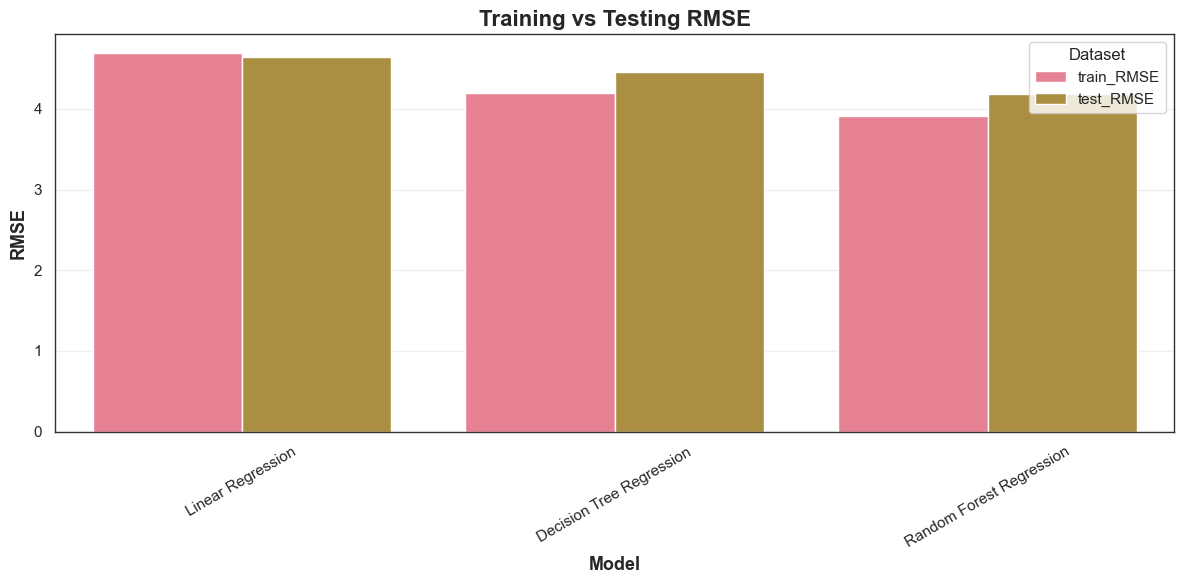

In [35]:
overfitting_melted = overfitting_df.melt(
    id_vars="model",
    value_vars=["train_RMSE", "test_RMSE"],
    var_name="dataset",
    value_name="RMSE"
)

plt.figure()
sns.barplot(
    data=overfitting_melted,
    x="model",
    y="RMSE",
    hue="dataset"
)
plt.title("Training vs Testing RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=30)
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

## 30. Save Model Evaluation Results

We save model comparison results as a CSV file.

### Why this step is needed

Saved results can be used later in reports, README updates, or final model comparison notebooks.

### Consequences if skipped

Results may be lost when the notebook is closed or rerun.

In [36]:
results_output_path = os.path.join(reports_output_dir, "baseline_model_results.csv")

results_df.to_csv(results_output_path, index=False)

print("Baseline model results saved to:", results_output_path)

Baseline model results saved to: ../reports\baseline_model_results.csv


## 31. Save Best Model Predictions

We save actual values, predicted values, and residuals for the best baseline model.

### Why this step is needed

Prediction outputs are useful for deeper error analysis in future notebooks.

### Consequences if skipped

Future residual or error analysis would need to be recreated from scratch.

In [37]:
predictions_output_path = os.path.join(reports_output_dir, "baseline_best_model_predictions.csv")

prediction_df.to_csv(predictions_output_path, index=False)

print("Best model predictions saved to:", predictions_output_path)

Best model predictions saved to: ../reports\baseline_best_model_predictions.csv


## 32. Save Best Baseline Model

We save the best trained baseline model using joblib.

### Why this step is needed

Saving the model allows it to be reused later without retraining.

### Consequences if skipped

The model must be retrained every time it is needed.

In [38]:
best_model_output_path = os.path.join(models_output_dir, "best_baseline_model.pkl")

joblib.dump(best_model, best_model_output_path)

print("Best baseline model saved to:", best_model_output_path)

Best baseline model saved to: ../models\best_baseline_model.pkl


## 33. Save Final Feature List Used by Best Model

We save the feature list used for baseline modeling.

### Why this step is needed

A saved feature list ensures that future predictions use the same input columns in the same order.

### Consequences if skipped

Future model usage may fail or produce incorrect predictions if feature columns are missing or reordered.

In [39]:
baseline_feature_list_output_path = os.path.join(reports_output_dir, "baseline_model_feature_list.csv")

pd.DataFrame({"feature": feature_cols}).to_csv(
    baseline_feature_list_output_path,
    index=False
)

print("Baseline model feature list saved to:", baseline_feature_list_output_path)

Baseline model feature list saved to: ../reports\baseline_model_feature_list.csv


## 34. Final Summary

In this notebook, we completed baseline regression modeling for glucose prediction.

### Completed Work

- Loaded modeling-ready dataset
- Loaded selected feature list
- Defined target variable and feature matrix
- Built baseline regression models
- Trained Linear Regression
- Trained Decision Tree Regression
- Trained Random Forest Regression
- Evaluated models using MAE, RMSE, and R²
- Compared random, chronological, and patient-level split strategies
- Visualized model performance
- Analyzed residuals
- Reviewed feature importance
- Checked for overfitting
- Saved model results
- Saved predictions
- Saved best baseline model

### Key Interpretation

The best baseline model should not be selected only because it performs well on a random split. For this dataset, chronological and patient-level splits are especially important because glucose readings are time-dependent and patient-specific.

### Recommended Next Step

The next notebook should focus on model improvement, including:

- hyperparameter tuning
- cross-validation
- stronger feature engineering
- testing additional models
- comparing tuned models against this baseline